In [0]:
from pyspark.sql.functions import col

appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]

df = spark.createDataFrame(appointments_data, columns)

display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


In [0]:
city_count_df = df.groupBy("city").count()

display(city_count_df)

city,count
Hyderabad,3
Bangalore,3
Mumbai,3
Delhi,3
Chennai,3


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

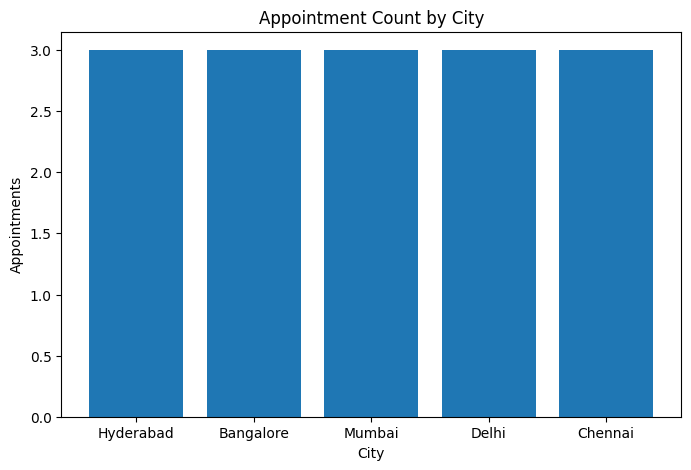

In [0]:
city_count = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointments")
plt.show()

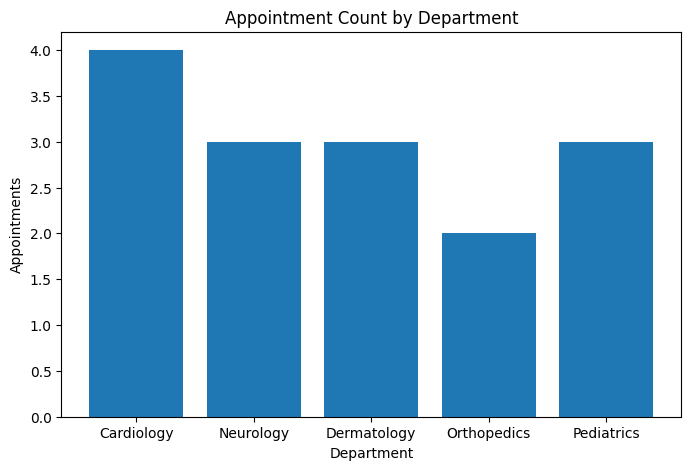

In [0]:
dept_count = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_count["department"], dept_count["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Appointments")
plt.show()

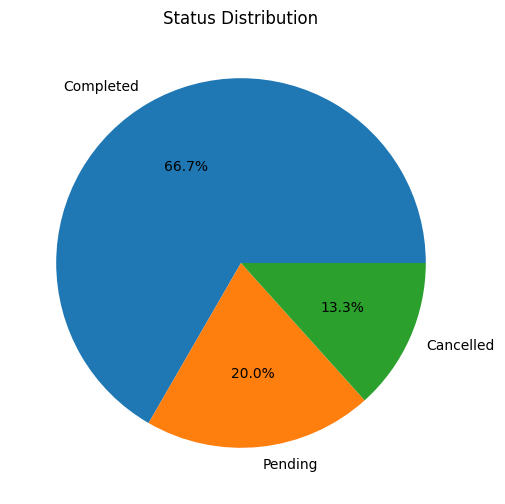

In [0]:
status_count = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_count["count"],
    labels=status_count["status"],
    autopct="%1.1f%%"
)
plt.title("Status Distribution")
plt.show()

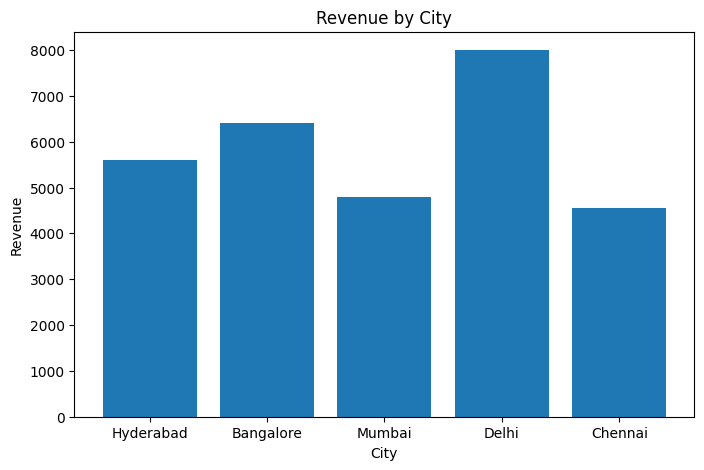

In [0]:
city_revenue = df.groupBy("city") \
.sum("consultation_fee") \
.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    city_revenue["city"],
    city_revenue["sum(consultation_fee)"]
)
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

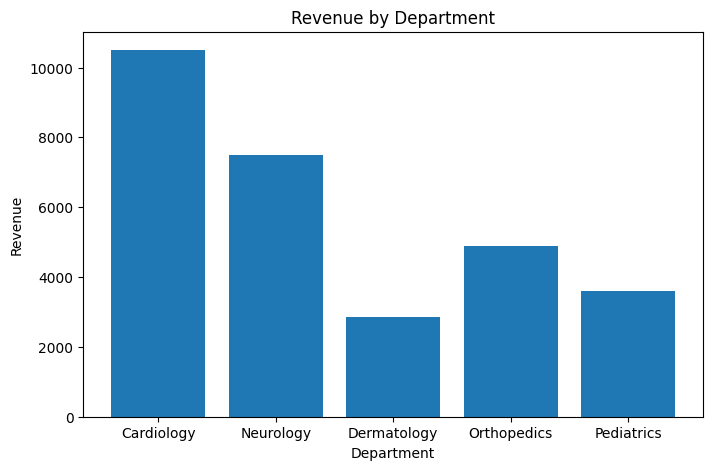

In [0]:
dept_revenue = df.groupBy("department") \
.sum("consultation_fee") \
.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    dept_revenue["department"],
    dept_revenue["sum(consultation_fee)"]
)
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

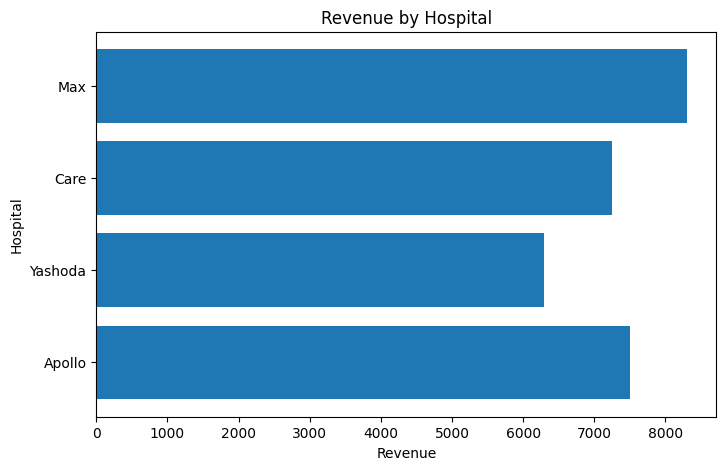

In [0]:
hospital_revenue = df.groupBy("hospital") \
.sum("consultation_fee") \
.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    hospital_revenue["hospital"],
    hospital_revenue["sum(consultation_fee)"]
)
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

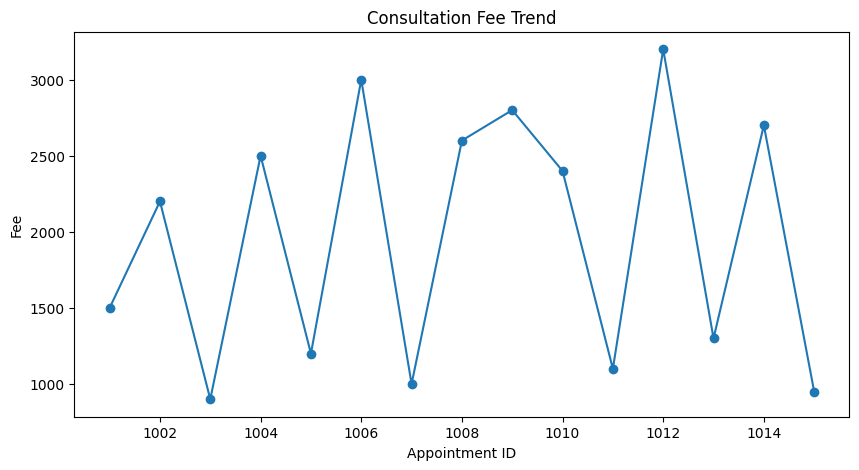

In [0]:
line_df = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(
    line_df["appointment_id"],
    line_df["consultation_fee"],
    marker="o"
)
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Fee")
plt.show()

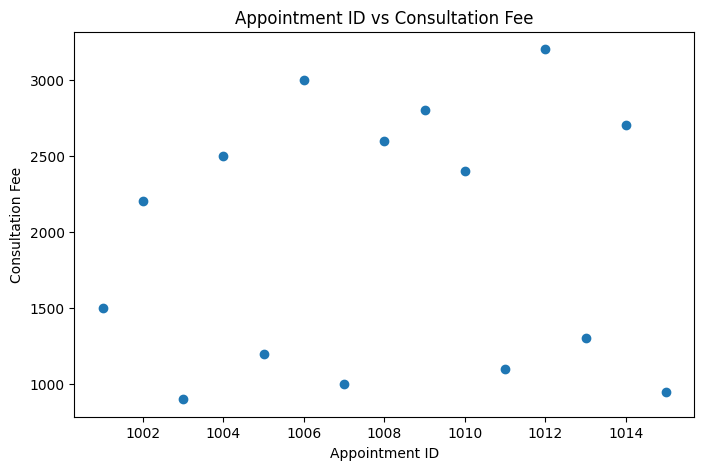

In [0]:
scatter_df = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    scatter_df["appointment_id"],
    scatter_df["consultation_fee"]
)
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

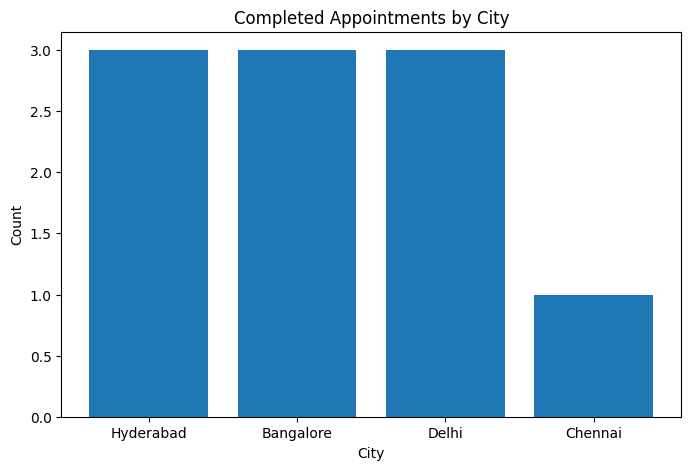

In [0]:
completed_df = df.filter(
    df.status == "Completed"
)

completed_city = completed_df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    completed_city["city"],
    completed_city["count"]
)
plt.title("Completed Appointments by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

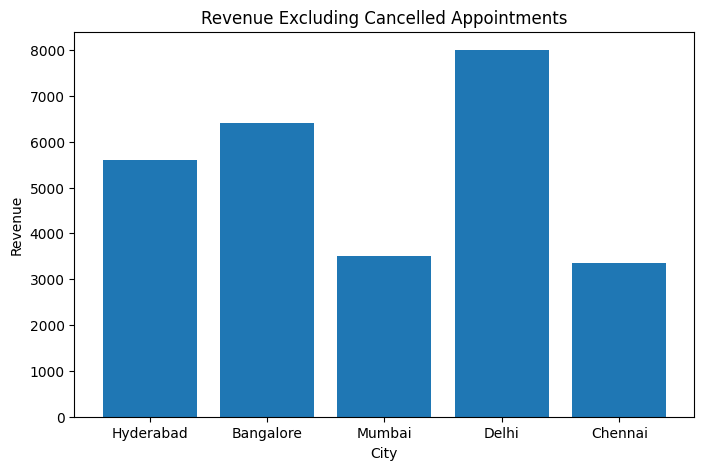

In [0]:
revenue_df = df.filter(
    df.status != "Cancelled"
)

revenue_city = revenue_df.groupBy("city") \
.sum("consultation_fee") \
.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    revenue_city["city"],
    revenue_city["sum(consultation_fee)"]
)
plt.title("Revenue Excluding Cancelled Appointments")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

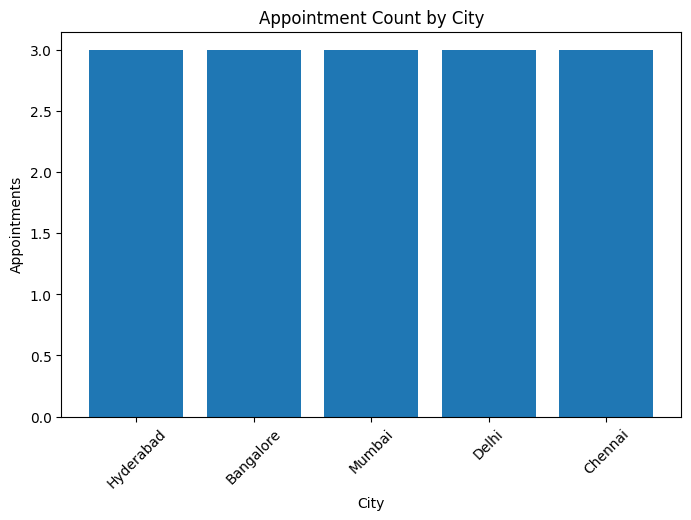

In [0]:
city_count = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])

plt.xticks(rotation=45)

plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointments")

plt.show()

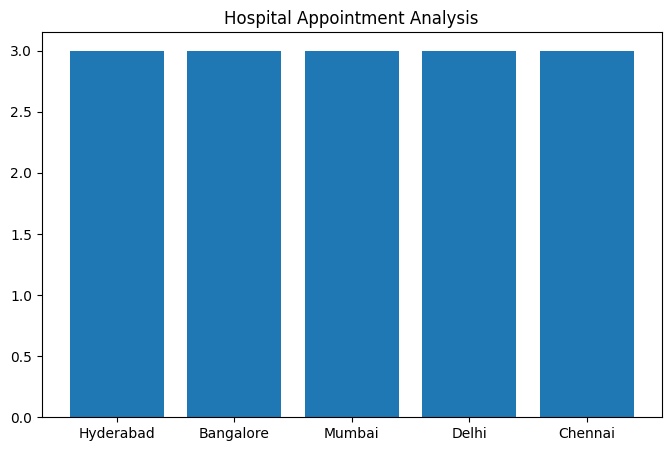

In [0]:
city_count = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])

plt.title("Hospital Appointment Analysis")

plt.show()

<Figure size 1200x600 with 0 Axes>

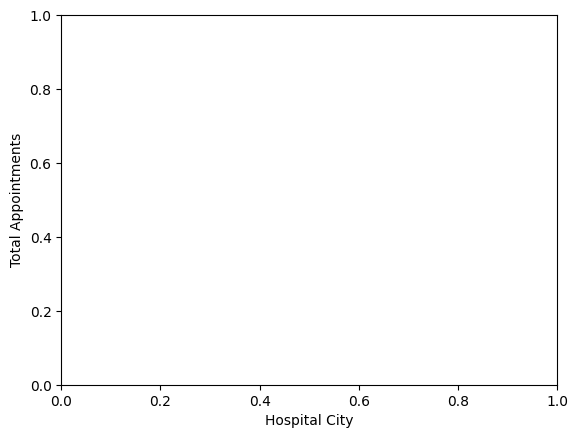

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [0]:
plt.xlabel("Hospital City")
plt.ylabel("Total Appointments")
plt.figure(figsize=(12,6))
plt.figure(figsize=(12,6))

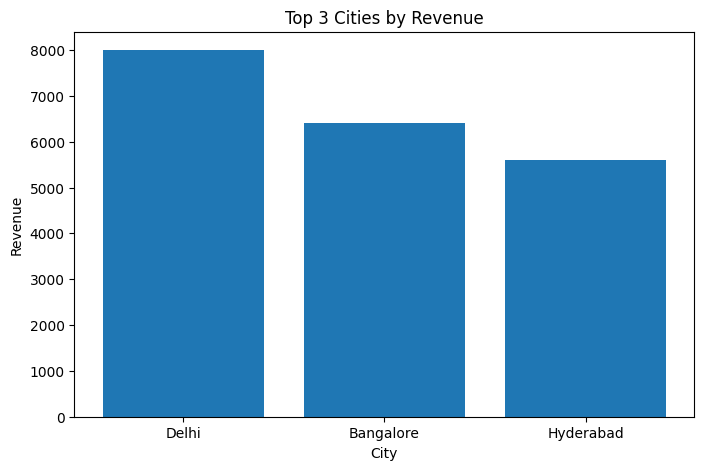

In [0]:
top_city = df.groupBy("city") \
.sum("consultation_fee") \
.toPandas()

top_city = top_city.sort_values(
    by="sum(consultation_fee)",
    ascending=False
).head(3)

plt.figure(figsize=(8,5))
plt.bar(
    top_city["city"],
    top_city["sum(consultation_fee)"]
)

plt.title("Top 3 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

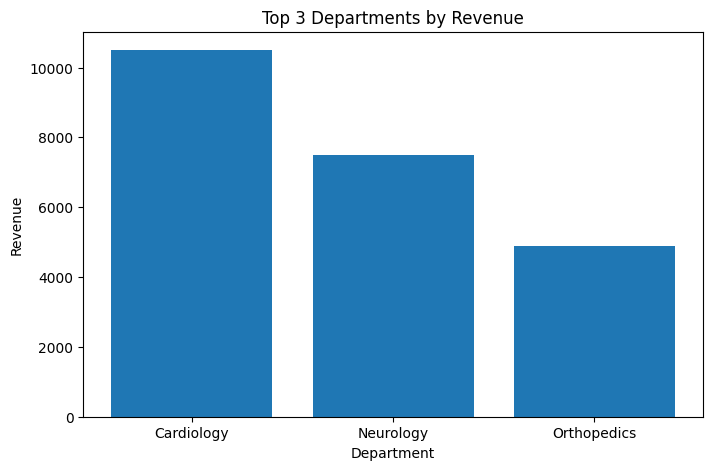

In [0]:
top_dept = df.groupBy("department") \
.sum("consultation_fee") \
.toPandas()

top_dept = top_dept.sort_values(
    by="sum(consultation_fee)",
    ascending=False
).head(3)

plt.figure(figsize=(8,5))
plt.bar(
    top_dept["department"],
    top_dept["sum(consultation_fee)"]
)

plt.title("Top 3 Departments by Revenue")
plt.xlabel("Department")
plt.ylabel("Revenue")

plt.show()

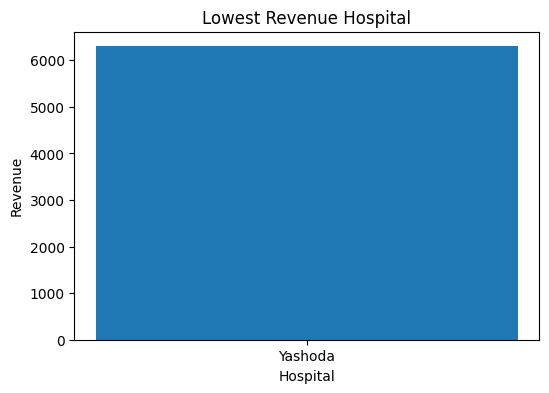

In [0]:
hospital_rev = df.groupBy("hospital") \
.sum("consultation_fee") \
.toPandas()

lowest = hospital_rev.sort_values(
    by="sum(consultation_fee)"
).head(1)

plt.figure(figsize=(6,4))
plt.bar(
    lowest["hospital"],
    lowest["sum(consultation_fee)"]
)

plt.title("Lowest Revenue Hospital")
plt.xlabel("Hospital")
plt.ylabel("Revenue")

plt.show()

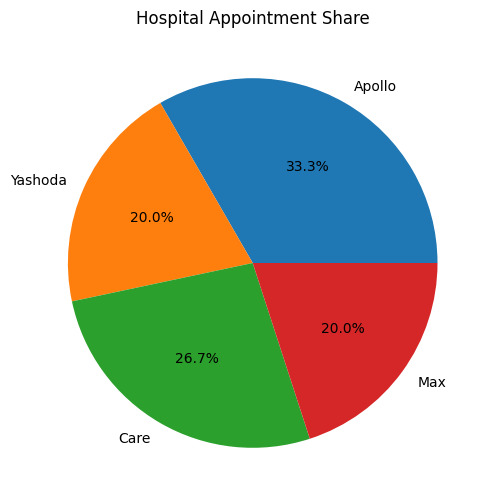

In [0]:
hospital_count = df.groupBy("hospital") \
.count() \
.toPandas()

plt.figure(figsize=(6,6))

plt.pie(
    hospital_count["count"],
    labels=hospital_count["hospital"],
    autopct="%1.1f%%"
)

plt.title("Hospital Appointment Share")

plt.show()

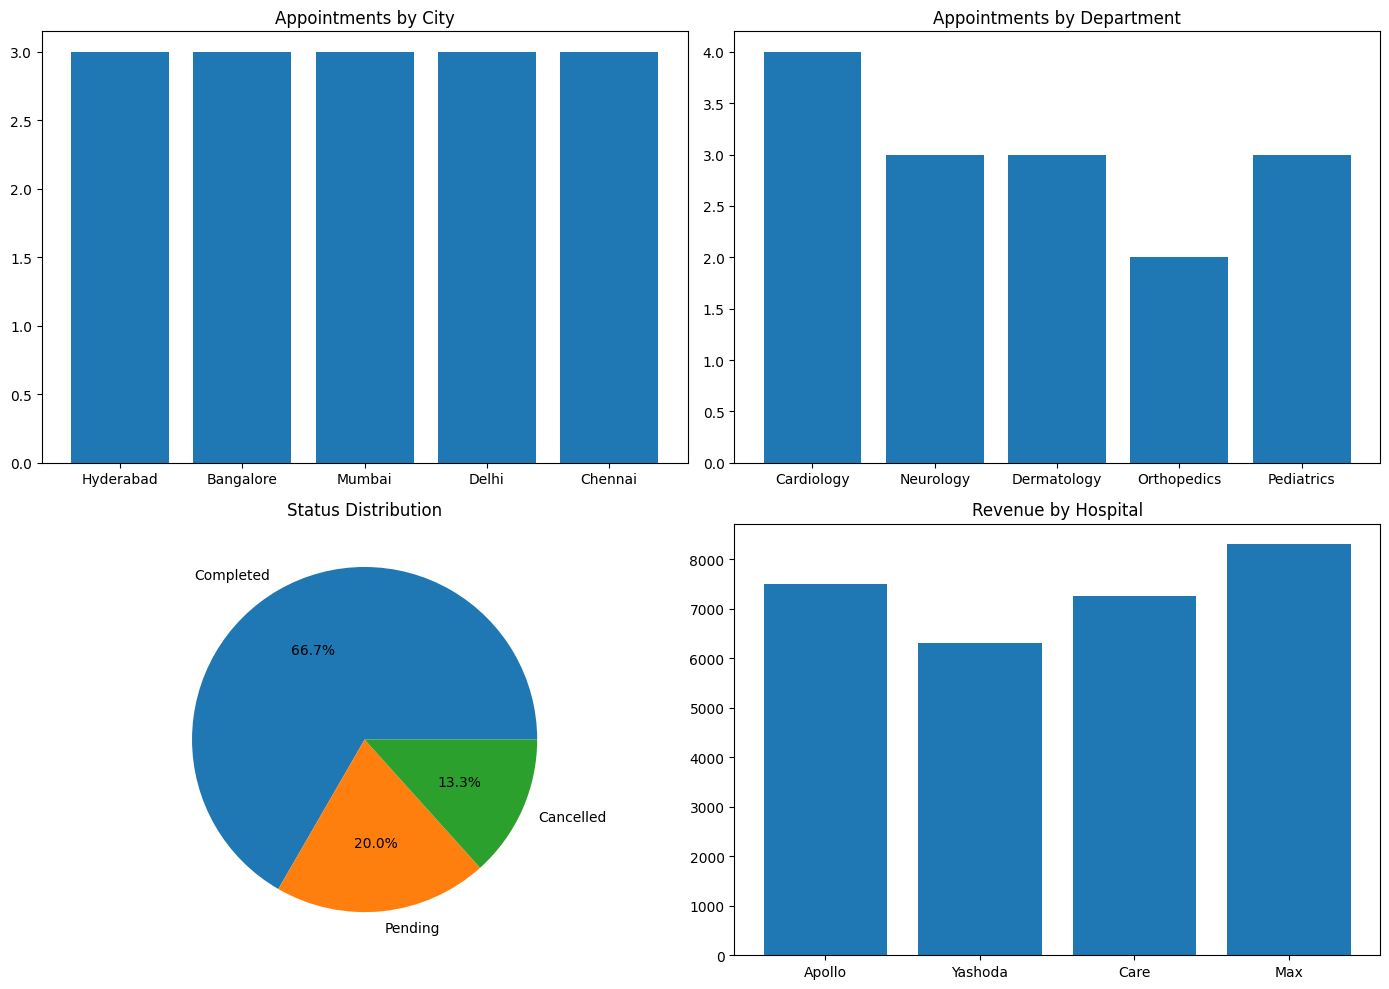

In [0]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# Chart 1
city_count = df.groupBy("city").count().toPandas()

ax[0,0].bar(
    city_count["city"],
    city_count["count"]
)
ax[0,0].set_title("Appointments by City")

# Chart 2
dept_count = df.groupBy("department").count().toPandas()

ax[0,1].bar(
    dept_count["department"],
    dept_count["count"]
)
ax[0,1].set_title("Appointments by Department")

# Chart 3
status_count = df.groupBy("status").count().toPandas()

ax[1,0].pie(
    status_count["count"],
    labels=status_count["status"],
    autopct="%1.1f%%"
)
ax[1,0].set_title("Status Distribution")

# Chart 4
hospital_rev = df.groupBy("hospital") \
.sum("consultation_fee") \
.toPandas()

ax[1,1].bar(
    hospital_rev["hospital"],
    hospital_rev["sum(consultation_fee)"]
)
ax[1,1].set_title("Revenue by Hospital")

plt.tight_layout()
plt.show()